# Sales & Demand Forecasting Project

This notebook demonstrates a business-friendly sales forecasting workflow. The goal is to prepare time-based data, build a forecasting model, evaluate performance, and present results for planning.

In [22]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', palette='muted', font_scale=1.1)

## 1. Create or load the sales dataset

This example uses a synthetic daily sales dataset that mimics a small retail business with trend, seasonality, and noise.

In [14]:
date_range = pd.date_range(start='2022-01-01', end='2024-12-31', freq='D')
np.random.seed(42)
trend = np.linspace(50, 130, len(date_range))
seasonality = 12 * np.sin(2 * np.pi * date_range.dayofyear / 365.25)
weekly = 10 * np.where(date_range.dayofweek < 5, 1, 0)
noise = np.random.normal(loc=0, scale=8, size=len(date_range))
sales = np.maximum(0, trend + seasonality + weekly + noise).round(0)

data = pd.DataFrame({'date': date_range, 'sales': sales})
data.head()

,date,sales
0,2022-01-01,54.0
1,2022-01-02,49.0
2,2022-01-03,66.0
3,2022-01-04,73.0
4,2022-01-05,59.0


## 2. Clean the data and build time-based features

Here we create features that capture the calendar and trend information used for forecasting.

In [23]:
data['date'] = pd.to_datetime(data['date'])
data['day_of_week'] = data['date'].dt.dayofweek
data['month'] = data['date'].dt.month
data['quarter'] = data['date'].dt.quarter
data['is_weekend'] = data['day_of_week'].isin([5, 6]).astype(int)
data['trend'] = np.arange(len(data))
data['rolling_7'] = data['sales'].rolling(window=7, min_periods=1).mean()
data['lag_7'] = data['sales'].shift(7).bfill()
data.tail()

,date,sales,day_of_week,month,quarter,is_weekend,trend,rolling_7,lag_7
1091,2024-12-27,139.0,4,12,4,0,1091,136.714286,140.0
1092,2024-12-28,135.0,5,12,4,1,1092,137.285714,131.0
1093,2024-12-29,130.0,6,12,4,1,1093,136.428571,136.0
1094,2024-12-30,146.0,0,12,4,0,1094,137.285714,140.0
1095,2024-12-31,140.0,1,12,4,0,1095,137.857143,136.0


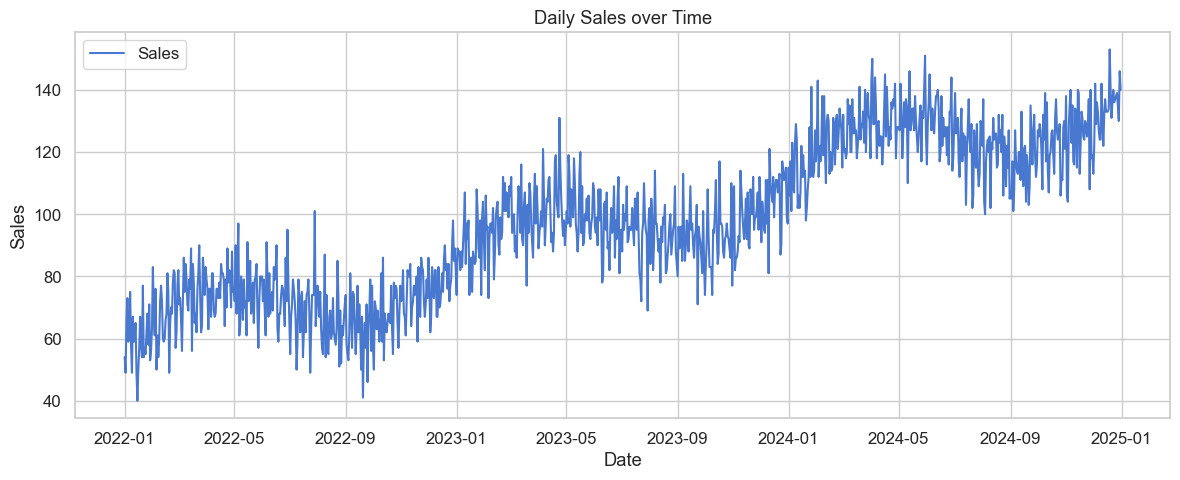

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(data['date'], data['sales'], label='Sales')
plt.title('Daily Sales over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Split the data and train a regression model

Using a time-based split keeps the forecast realistic for future dates.

In [18]:
train_end = '2024-06-30'
train = data[data['date'] <= train_end].copy()
test = data[data['date'] > train_end].copy()
features = ['day_of_week', 'month', 'quarter', 'is_weekend', 'trend', 'rolling_7', 'lag_7']
X_train = train[features]
y_train = train['sales']
X_test = test[features]
y_test = test['sales']
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions, squared=False)
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')

KeyError: "['lag_7'] not in index"

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(test['date'], y_test, label='Actual', alpha=0.8)
plt.plot(test['date'], predictions, label='Forecast', alpha=0.8)
plt.title('Actual vs Forecasted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'y_test' is not defined

<Figure size 1200x500 with 0 Axes>

## 4. Forecast the next 30 days

We generate future calendar features and predict sales for the next month.

In [20]:
future_dates = pd.date_range(start=data['date'].max() + pd.Timedelta(days=1), periods=30, freq='D')
future = pd.DataFrame({'date': future_dates})
future['day_of_week'] = future['date'].dt.dayofweek
future['month'] = future['date'].dt.month
future['quarter'] = future['date'].dt.quarter
future['is_weekend'] = future['day_of_week'].isin([5, 6]).astype(int)
future['trend'] = np.arange(len(data), len(data) + len(future))
future['rolling_7'] = data['sales'].iloc[-7:].mean()
future['lag_7'] = data['sales'].iloc[-7] if len(data) >= 7 else data['sales'].iloc[-1]
future['forecast_sales'] = model.predict(future[features])
future[['date', 'forecast_sales']].head()

NameError: name 'model' is not defined

KeyError: 'forecast_sales'

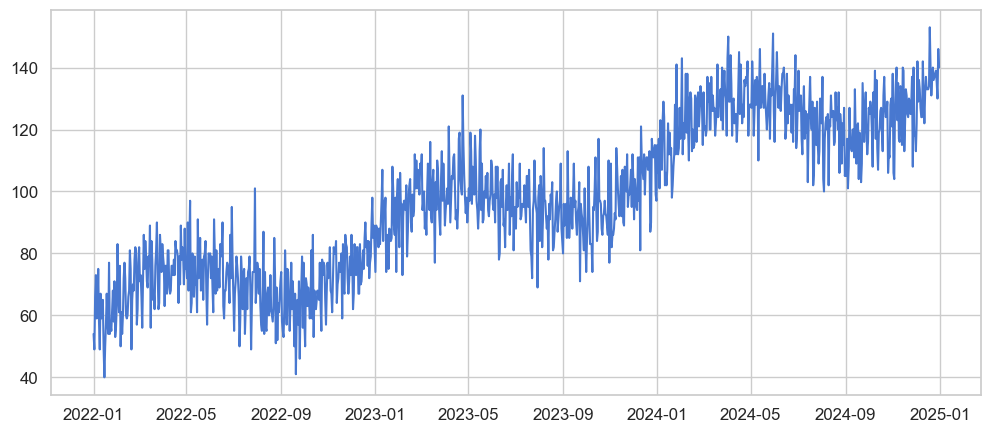

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(data['date'], data['sales'], label='Historical Sales')
plt.plot(future['date'], future['forecast_sales'], label='30-Day Forecast', linestyle='--')
plt.title('Historical Sales and 30-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Business interpretation

- The forecast shows expected demand for the next 30 days based on the recent trend and seasonality.
- A retailer can use this forecast to plan inventory purchases, staff scheduling, and cash flow.
- If forecast values rise above normal levels, the business should prepare by ordering more stock and increasing staffing on busier days.
- If demand slows, the business can reduce inventory orders and avoid overstock costs.